# Comparing v1 and v2 datasets

Compare images in `roman_data_challenge_rung_0_v_2_0.h5` and `roman_data_challenge_rung_0_v_1_0.h5`.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import SymLogNorm
from tqdm.auto import tqdm

from mejiro.utils import util

In [8]:
label = 'roman_data_challenge_rung_0'
v2_filepath = f'/data/bwedig/mejiro/{label}/06/{label}_v_2_0.h5'
v1_filepath = f'/data/bwedig/mejiro/{label}/06/{label}_v_1_2.h5'

f_v2 = h5py.File(v2_filepath, 'r')
f_v1 = h5py.File(v1_filepath, 'r')

images_v2 = f_v2['images']
images_v1 = f_v1['images']

bands = ['F106', 'F129', 'F158']
band_colors = {'F106': 'tab:blue', 'F129': 'tab:green', 'F158': 'tab:red'}

In [9]:
# Unit conversion constants
# v1 (galsim engine): Counts  [galsim Roman gain = 1.0 e-/DN, so Counts ≈ electrons ≈ DN]
# v2 (romanisim engine): DN/s  [romanisim gain = 2.0 e-/DN]
# To compare apples-to-apples, convert v1 Counts → DN/s:
#   v1_dnps = v1_counts / (ROMANISIM_GAIN * exposure_time)
ROMANISIM_GAIN = 2.0  # e-/DN, from romanisim.parameters.reference_data['gain']

In [10]:
common_keys = sorted(set(images_v2.keys()) & set(images_v1.keys()))
print(f'Number of systems in common: {len(common_keys)}')

chi2_vals = {band: [] for band in bands}

for key in tqdm(common_keys):
    sl_v2 = images_v2[key]
    sl_v1 = images_v1[key]
    uid = sl_v2.attrs['uid'][0]

    for band in bands:
        ds_name = f'exposure_{uid}_{band}'
        if ds_name not in sl_v2 or ds_name not in sl_v1:
            continue
        img_v2 = sl_v2[ds_name][:]
        img_v1 = sl_v1[ds_name][:]

        # crop v1 (91x91) to match v2 (73x73)
        img_v1 = util.center_crop_image(img_v1, img_v2.shape)

        # convert v1 Counts → DN/s to match v2 units
        exp_time = float(sl_v1[ds_name].attrs['exposure_time'][0])
        img_v1 = img_v1 / (ROMANISIM_GAIN * exp_time)

        # chi2 per pixel: (v2 - v1)^2 / |v1|, using v1 as the expected value
        mask = img_v1 > 0
        chi2 = np.zeros_like(img_v2, dtype=float)
        chi2[mask] = (img_v2[mask] - img_v1[mask]) ** 2 / img_v1[mask]
        chi2_vals[band].append(chi2[mask].ravel())

chi2_vals = {band: np.concatenate(arrs) for band, arrs in chi2_vals.items() if arrs}
for band, arr in chi2_vals.items():
    print(f'{band}: {arr.size} pixels, median chi2 = {np.median(arr):.4f}, mean chi2 = {np.mean(arr):.4f}')


Number of systems in common: 11160


  0%|          | 0/11160 [00:00<?, ?it/s]

F106: 59471640 pixels, median chi2 = 0.1078, mean chi2 = 0.1114
F129: 59471640 pixels, median chi2 = 0.1317, mean chi2 = 0.1350
F158: 59471640 pixels, median chi2 = 0.1410, mean chi2 = 0.1440


## Histogram of chi2 per pixel by band

chi2 = (v2 - v1)^2 / v1, treating the converted v1 (DN/s) as the expected value. Only pixels where v1 > 0 are included. For a well-matched Poisson image pair the distribution should peak near 1. Broad tails reflect sky-background and noise-model differences between the galsim (v1) and romanisim (v2) engines.


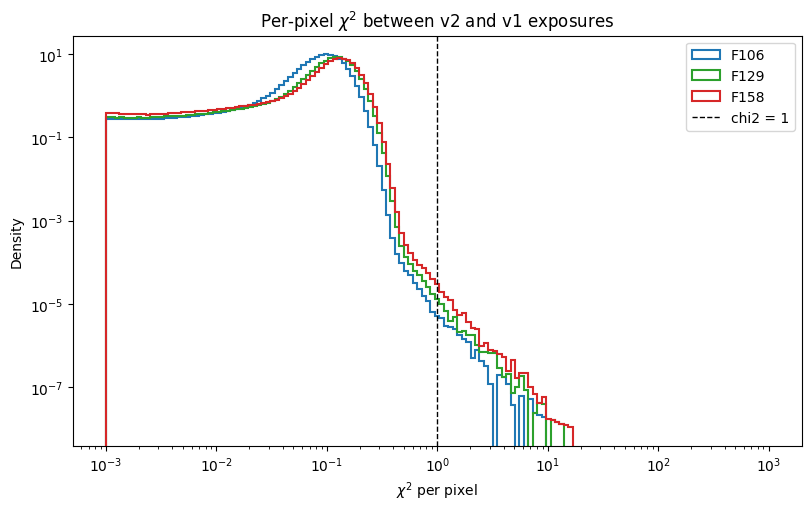

In [11]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

bin_edges = np.logspace(-3, 3, 150)
for band in bands:
    if band not in chi2_vals:
        continue
    ax.hist(chi2_vals[band], bins=bin_edges, histtype='step', linewidth=1.5,
            color=band_colors[band], label=band, density=True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1, color='k', linestyle='--', linewidth=1, label='chi2 = 1')
ax.set_xlabel(r'$\chi^2$ per pixel')
ax.set_ylabel('Density')
ax.set_title(r'Per-pixel $\chi^2$ between v2 and v1 exposures')
ax.legend()
plt.show()


## Example exposures: v2, v1, and residual

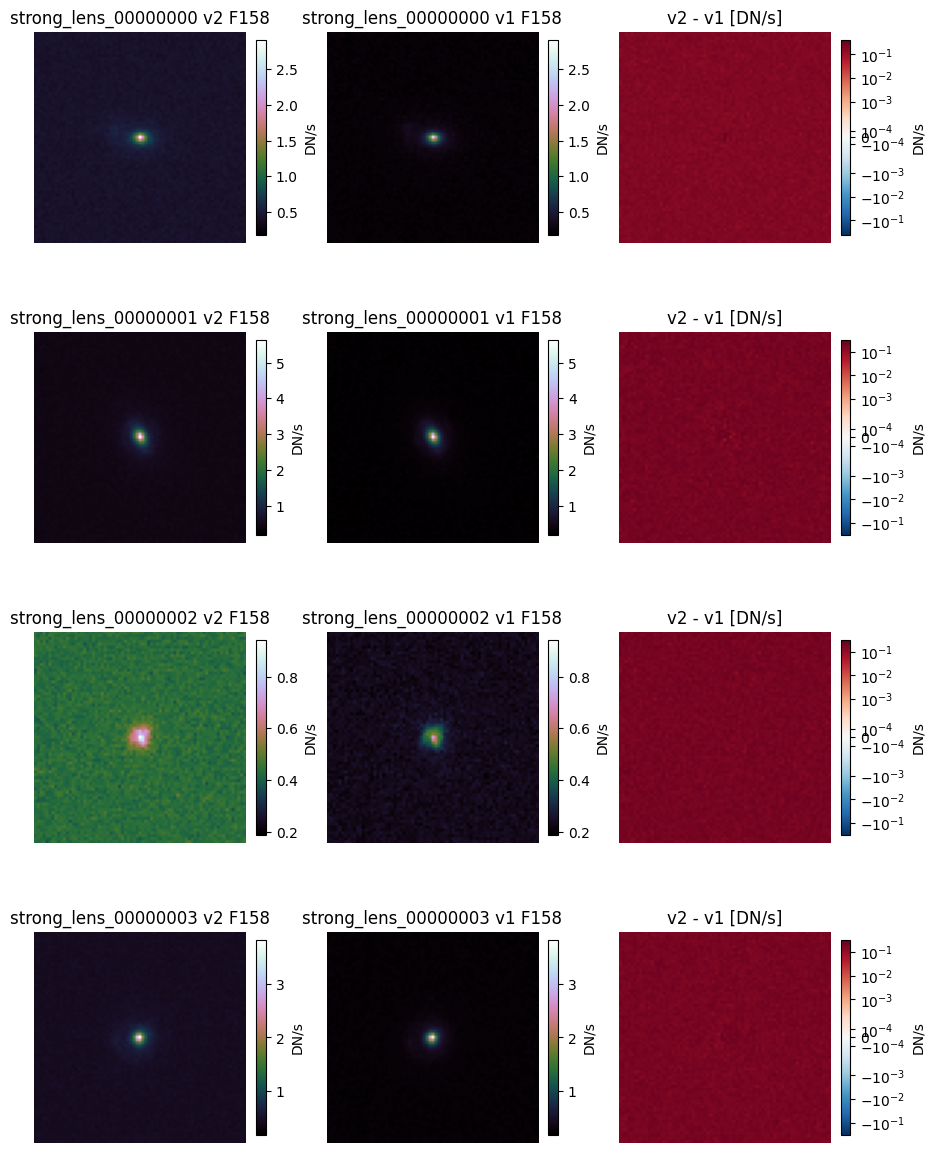

In [12]:
n_examples = 4
example_keys = common_keys[:n_examples]
band = 'F158'

fig, axes = plt.subplots(n_examples, 3, figsize=(9, 3 * n_examples), constrained_layout=True)
if n_examples == 1:
    axes = axes[np.newaxis, :]

for row, key in enumerate(example_keys):
    uid = images_v2[key].attrs['uid'][0]
    ds_name = f'exposure_{uid}_{band}'
    img_v2 = images_v2[key][ds_name][:]
    img_v1 = images_v1[key][ds_name][:]

    # crop v1 (91x91) to match v2 (73x73)
    img_v1 = util.center_crop_image(img_v1, img_v2.shape)

    # convert v1 Counts → DN/s to match v2 units
    exp_time = float(images_v1[key][ds_name].attrs['exposure_time'][0])
    img_v1 = img_v1 / (ROMANISIM_GAIN * exp_time)

    residual = img_v2 - img_v1

    vmin = min(img_v2.min(), img_v1.min())
    vmax = max(img_v2.max(), img_v1.max())
    rmax = np.max(np.abs(residual))
    rlin = max(rmax * 1e-3, 1e-6)

    im0 = axes[row, 0].imshow(img_v2, origin='lower', cmap='cubehelix', vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f'{key} v2 {band}')
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046, label='DN/s')

    im1 = axes[row, 1].imshow(img_v1, origin='lower', cmap='cubehelix', vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f'{key} v1 {band}')
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, label='DN/s')

    im2 = axes[row, 2].imshow(residual, origin='lower', cmap='RdBu_r',
                              norm=SymLogNorm(linthresh=rlin, vmin=-rmax, vmax=rmax))
    axes[row, 2].set_title('v2 - v1 [DN/s]')
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, label='DN/s')

    for a in axes[row]:
        a.axis('off')

plt.show()

In [13]:
f_v2.close()
f_v1.close()